Zadanie 10

Wyczyść dataset Titanic stosując pełny pipeline:
- Usuń kolumny z >60% NaN
- Wypełnij Age medianą
- Wypełnij Embarked dominantą
- Usuń wiersze z pozostałymi NaN

Wymagania:
- Przed i po: wypisz kształt DataFrame
- Sprawdź czy nie ma NaN
- Porównaj rozkład Age przed i po

Kształt Titanic DataFrame przed operacjami: (891, 12)
Kształt Titanic DataFrame po operacji usunięcia kolumn z > 60% NaN: (891, 11)
Usunięte kolumny: {'Cabin'}
Mediana dla Age: 28.0

Age po wypełnienie medianą:
count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64

Dominanta dla Embarked: S
Embarked po wypełnieniu dominantą:
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64
Kształt Titanic DataFrame po operacjach: (891, 11)

Przed usunięciem wartości NaN z kolumn:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Po usunięciu wartości NaN z kolumn:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp  

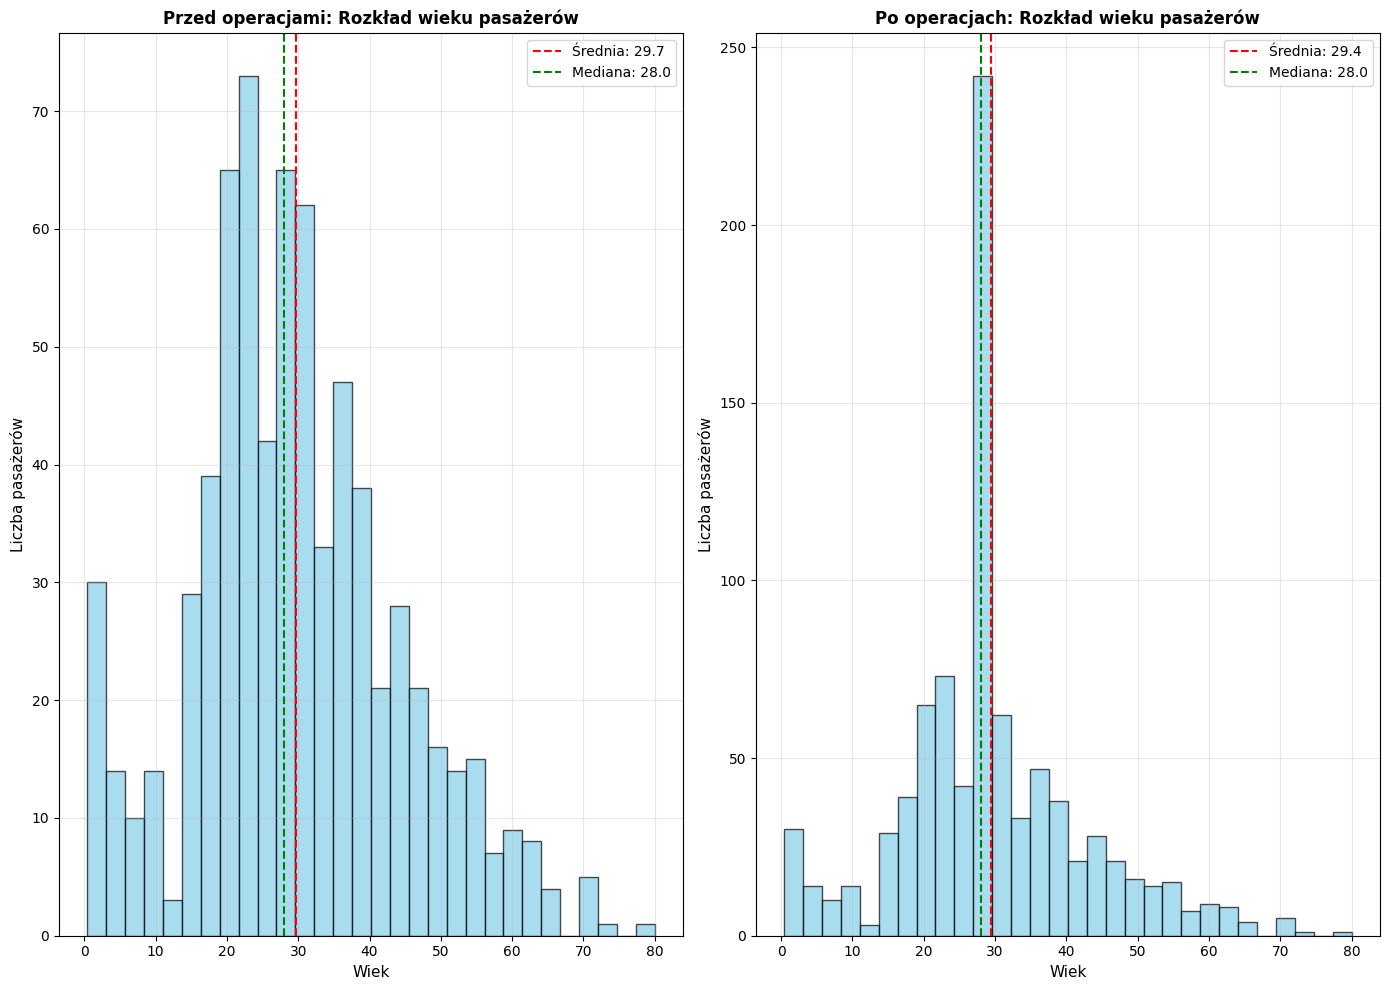

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic = pd.read_csv(url)

titanic_clean = titanic.copy()

# Usunięce kolumn z > 60% NaN
threshold_rows = len(titanic) * 0.6 # 60 % wierszy
titanic_clean = titanic_clean.dropna(thresh=threshold_rows, axis=1)
shape_after_dropped_cols = titanic_clean.shape
all_dropped_cols = set(titanic.columns) - set(titanic_clean.columns)

# Wypełnienie Age medianą
age_median = titanic_clean['Age'].median()
titanic_clean['Age'] = titanic_clean['Age'].fillna(age_median)

# Wypełnienie Embarked dominantą
embarked_mode = titanic_clean['Embarked'].mode()[0]
titanic_clean['Embarked'] = titanic_clean['Embarked'].fillna(embarked_mode)

# Usuwanie wierszy z pozostałymi NaN
titanic_clean = titanic_clean.dropna()

print(f"Kształt Titanic DataFrame przed operacjami: {titanic.shape}")
print(f"Kształt Titanic DataFrame po operacji usunięcia kolumn z > 60% NaN: {shape_after_dropped_cols}")
print(f"Usunięte kolumny: {all_dropped_cols}")
print(f"Mediana dla Age: {age_median}")
print(f"\nAge po wypełnienie medianą:")
print(titanic_clean['Age'].describe())
print(f"\nDominanta dla Embarked: {embarked_mode}")
print(f"Embarked po wypełnieniu dominantą:")
print(titanic_clean['Embarked'].value_counts())
print(f"Kształt Titanic DataFrame po operacjach: {titanic_clean.shape}")

print("\nPrzed usunięciem wartości NaN z kolumn:")
print(titanic.isna().sum())
print("\nPo usunięciu wartości NaN z kolumn:")
print(titanic_clean.isna().sum())

print(f"\nPrzed: Średnia wieku = {titanic['Age'].mean():.2f}, liczba pasażerów = {titanic['Age'].count()}")
print(f"Po: średnia wieku = {titanic_clean['Age'].mean():.2f}, liczba pasażerów = {titanic_clean['Age'].count()}")

print("\nRozkład wieku: ")
print("Przed: ")
print(titanic['Age'].value_counts())

print("\nPo:")
print(titanic_clean['Age'].value_counts())

# Wizualiazcja
fig, axes = plt.subplots(1, 2, figsize=(14, 10))

# Rozkład wieku przed
axes[0].hist(titanic['Age'], bins=30, color='skyblue',
                edgecolor='black', alpha=0.7)
axes[0].axvline(titanic['Age'].mean(), color='red', linestyle='--',
label=f'Średnia: {titanic["Age"].mean():.1f}')
axes[0].axvline(titanic['Age'].median(), color='green',
linestyle='--', label=f'Mediana: {titanic["Age"].median():.1f}')
axes[0].set_xlabel('Wiek', fontsize=11)
axes[0].set_ylabel('Liczba pasażerów', fontsize=11)
axes[0].set_title('Przed operacjami: Rozkład wieku pasażerów', fontsize=12,
fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Rozkład wieku po
axes[1].hist(titanic_clean['Age'], bins=30, color='skyblue',
                edgecolor='black', alpha=0.7)
axes[1].axvline(titanic_clean['Age'].mean(), color='red', linestyle='--',
label=f'Średnia: {titanic_clean["Age"].mean():.1f}')
axes[1].axvline(titanic_clean['Age'].median(), color='green',
linestyle='--', label=f'Mediana: {titanic_clean["Age"].median():.1f}')
axes[1].set_xlabel('Wiek', fontsize=11)
axes[1].set_ylabel('Liczba pasażerów', fontsize=11)
axes[1].set_title('Po operacjach: Rozkład wieku pasażerów', fontsize=12,
fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()